# Latin America Real-Time Macro: Offline Data Cartridges, Revision Triangles, and Mankiw-Shapiro Analysis

**How do central banks and macroeconomic researchers in Latin America track monetary policy and economic activity in real time, how large are subsequent data revisions to preliminary releases, and how can immutable, authenticated data cartridges guarantee exact empirical replicability despite upstream statistical agency API shifts?**

Macroeconomic surveillance in emerging markets—particularly across Latin America—requires navigating severe real-time information frictions. Monetary authorities including Banco de México (Banxico), Banco Central do Brasil (BCB), and Banco Central de Chile (BCCh) operate under heightened external vulnerability, where policy interest rates (TIIE objetivo, Taxa Selic, and TPM) must react promptly to emerging domestic output and price developments. However, the national accounts data published by statistical agencies (such as INEGI in Mexico or IBGE in Brazil) are preliminary estimates based on incomplete monthly indicator samples. Over successive months and quarters, these preliminary figures undergo substantial retrospective revisions as late survey responses arrive, informal sector outputs are imputed, and annual benchmark reconciliations occur.

Determining whether macroeconomic revisions represent **news** (efficient forecasting updates incorporating new economic information) or **noise** (transitory measurement errors) is essential for macroeconomic stability. If revisions are primarily noise, central banks that react aggressively to initial releases inadvertently inject spurious volatility into the real economy. If revisions represent news, preliminary releases efficiently summarize all available data and policy should respond immediately. Furthermore, empirical research in Latin American macroeconomics is frequently disrupted when central bank or statistical agency APIs alter endpoints, modify JSON response schemas, or require proprietary authentication tokens. Self-verifying `.pmz` data cartridges package multi-country real-time vintage panels into immutable, cryptographically hashed capsules that execute completely offline in browser and Pyodide environments. This notebook demonstrates the full workflow: assembling a multi-country Latin American vintage panel, packaging and verifying offline `.pmz` cartridges, constructing real-time revision triangles, and conducting Mankiw-Shapiro (1986) news versus noise econometrics.

## The method in math — Latin America Real-Time Vintages, Revision Triangles, and Mankiw-Shapiro Econometrics

**1. Real-Time Vintage Matrix and Revision Dynamics.** Let $y_{i, t, v}$ denote the value of macroeconomic indicator $i$ for reference quarter $t$ published in vintage edition $v$ (where publication date $v \ge t$). For a balanced vintage sequence, the historical revision triangle matrix $\mathbf{T}[t, v]$ arranges reference dates along rows and publication vintages along columns:
$$ \mathbf{T} = \begin{bmatrix} y_{t_1, v_1} & y_{t_1, v_2} & \dots & y_{t_1, v_K} \\ \text{NaN} & y_{t_2, v_2} & \dots & y_{t_2, v_K} \\ \vdots & \vdots & \ddots & \vdots \\ \text{NaN} & \text{NaN} & \dots & y_{t_K, v_K} \end{bmatrix}. $$
Let $y_t^{(0)} = y_{t, v_0(t)}$ denote the initial preliminary release and $y_t^{(F)} = y_{t, v_{\max}}$ the latest benchmark release. The total revision is defined as:
$$ r_t \equiv y_t^{(F)} - y_t^{(0)}. $$

**2. Mankiw-Shapiro (1986) News vs. Noise Econometric Tests.** Under rational expectations and efficient statistical agency reporting, revisions are classified into two competing structural hypotheses:
- **News Hypothesis ($H_{\text{News}}$):** The preliminary release $y_t^{(0)}$ is an optimal mathematical projection of the final value $y_t^{(F)}$ onto the preliminary information set $\Omega_0$. The revision $r_t$ represents unpredictable innovation news and must be orthogonal to $y_t^{(0)}$:
  $$ r_t = \alpha_p + \beta_p y_t^{(0)} + \varepsilon_{p, t}, \quad H_0^{\text{News}}: \beta_p = 0. $$
- **Noise Hypothesis ($H_{\text{Noise}}$):** The preliminary release is the true final value contaminated with classical measurement error $u_t$: $y_t^{(0)} = y_t^{(F)} + u_t$, where $\operatorname{Cov}(y_t^{(F)}, u_t) = 0$. The revision $r_t = -u_t$ is correlated with the preliminary release but must be orthogonal to the final release $y_t^{(F)}$:
  $$ r_t = \alpha_f + \beta_f y_t^{(F)} + \varepsilon_{f, t}, \quad H_0^{\text{Noise}}: \beta_f = 0. $$
The noise share of preliminary release variance is quantified as:
$$ \text{Noise Share} = \max(0, -\beta_p) = \frac{\operatorname{Var}(u_t)}{\operatorname{Var}(y_t^{(0)})}. $$

**3. Cryptographic Data Cartridge Authentication.** Data cartridges (`.pmz`) guarantee offline empirical replicability via cryptographic digest hashing:
$$ \mathcal{H}_{\text{data}} = \operatorname{SHA256}(\operatorname{bytes}(df)), \quad \text{verified on unpack against metadata manifest.} $$

## Intuition

**Intuition.** Policymakers at Banco de México, Banco Central do Brasil, and Banco Central de Chile make real-time interest rate decisions based on imperfect preliminary snapshots of economic growth and inflation. When the national statistical institute releases initial GDP growth for the previous quarter, that estimate reflects only a fraction of completed business surveys and relies heavily on statistical imputation for informal economic activity. Over subsequent quarters, as comprehensive corporate tax filings and late census data are processed, statistical agencies publish revised figures that can alter the perceived stance of the business cycle.

The Mankiw-Shapiro econometric framework evaluates how policymakers should interpret these revisions. If statistical agencies construct preliminary releases as rational forecasts given incomplete information, revisions represent genuine economic *news*. In this scenario, revisions cannot be forecasted from the preliminary data ($\beta_p = 0$), implying that central banks cannot improve upon the initial release and should treat it as an unbiased signal. Conversely, if preliminary estimates are corrupted by classical measurement error (*noise*), the revision is negatively correlated with the initial release ($\beta_p < 0$) and orthogonal to the final benchmark ($\beta_f = 0$). Under the noise hypothesis, central bankers who react aggressively to preliminary growth numbers end up chasing statistical artifacts, amplifying output volatility.

To enable rigorous macroeconomic analysis without dependency on external network sockets, API rate limits, or credentials, `puremacro` introduces self-verifying data cartridges (`.pmz`). The cartridge bundles multi-country vintage panels, canonical series metadata, and cryptographic SHA-256 signatures into a single compressed binary capsule. When loaded offline, the cartridge verifies data integrity and exposes the full `VintagePanel` analytical interface (`coverage()`, `as_of()`, `triangle()`, `revisions()`, and `news_or_noise()`), guaranteeing 100% browser and Pyodide compatibility.

In [1]:
# Preamble: import numerical libraries, plotting style, and realtime panel tools
import sys
from pathlib import Path
import tempfile
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch.realtime import (
    VintagePanel,
    pack_realtime_cartridge,
    load_realtime_cartridge,
)

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

print("Latin America Real-Time Ecosystem: Banxico, INEGI, BCB, BCCh")

Latin America Real-Time Ecosystem: Banxico, INEGI, BCB, BCCh


In [2]:
# --- Experiment 1: Assemble Multi-Country Latin America Real-Time Vintage Panel ---
# Construct quarterly reference periods: 2022Q1 to 2025Q3 (15 reference quarters)
# Publication vintages: 8 quarterly vintages spanning 2024Q1 to 2025Q4
ref_dates = pd.date_range("2022-01-01", "2025-07-01", freq="QS").strftime("%Y-%m-%d").tolist()
vintage_dates = pd.date_range("2024-01-01", "2025-10-01", freq="QS").strftime("%Y-%m-%d").tolist()

rows = []
for v_idx, v in enumerate(vintage_dates):
    for d_idx, d in enumerate(ref_dates):
        if d <= v:
            # Mexico: Real GDP (INEGI indicator 735848) with realistic preliminary measurement noise
            base_gdp = 24000000.0 + 150000.0 * d_idx
            noise = float(rng.normal(0, 50000.0)) if d == v or (pd.to_datetime(v) - pd.to_datetime(d)).days <= 180 else 0.0
            rows.append({
                "country": "MEX", "variable": "gdp_real", "date": d, "vintage": v,
                "value": base_gdp + noise, "provider": "inegi", "series_id": "735848", "units": "MXN_millions"
            })
            # Mexico: Policy rate (Banxico TIIE objetivo, series SF61745)
            rows.append({
                "country": "MEX", "variable": "policy_rate", "date": d, "vintage": v,
                "value": 11.25 - 0.25 * d_idx, "provider": "banxico", "series_id": "SF61745", "units": "percent"
            })
            # Brazil: Policy rate (BCB Taxa Selic, series 432)
            rows.append({
                "country": "BRA", "variable": "policy_rate", "date": d, "vintage": v,
                "value": 12.75 - 0.50 * d_idx, "provider": "bcb", "series_id": "432", "units": "percent"
            })
            # Chile: Policy rate (BCCh TPM, series F022.TPM.TPO.D001.NO.Z.D)
            rows.append({
                "country": "CHL", "variable": "policy_rate", "date": d, "vintage": v,
                "value": 9.50 - 0.75 * d_idx, "provider": "bcch", "series_id": "F022.TPM.TPO.D001.NO.Z.D", "units": "percent"
            })

df_raw = pd.DataFrame(rows)
panel_raw = VintagePanel(df_raw)

print(f"Constructed Multi-Country Vintage Panel:")
print(f"  Total Observations : {len(panel_raw):,}")
print(f"  Countries Included : {panel_raw.countries}")
print(f"  Macro Variables    : {panel_raw.variables}")
print(f"  Reference Periods  : {len(ref_dates)} quarters ({ref_dates[0]} to {ref_dates[-1]})")
print(f"  Vintages Available : {len(vintage_dates)} releases ({vintage_dates[0]} to {vintage_dates[-1]})")

# Panel structural assertions
assert panel_raw.countries == ["BRA", "CHL", "MEX"]
assert "policy_rate" in panel_raw.variables
assert "gdp_real" in panel_raw.variables
assert len(panel_raw) > 300

Constructed Multi-Country Vintage Panel:
  Total Observations : 396
  Countries Included : ['BRA', 'CHL', 'MEX']
  Macro Variables    : ['gdp_real', 'policy_rate']
  Reference Periods  : 15 quarters (2022-01-01 to 2025-07-01)
  Vintages Available : 8 releases (2024-01-01 to 2025-10-01)


In [3]:
# --- Experiment 2: Self-Verifying Cryptographic Cartridge Packaging & Loading ---
# Package panel into an offline .pmz cartridge with SHA-256 verification
with tempfile.TemporaryDirectory() as tmp_dir:
    cartridge_file = Path(tmp_dir) / "latam_realtime_macro.pmz"
    pack_realtime_cartridge(
        panel_raw,
        cartridge_file,
        source="Banxico, INEGI, BCB, BCCh Regional Real-Time Ecosystem",
        vintage="2026-04-01",
        notes="Latin America central bank real-time macroeconomic vintage cartridge",
    )
    assert cartridge_file.exists(), "Cartridge file must be created on disk"
    loaded_panel = load_realtime_cartridge(cartridge_file, verify=True)

print(f"Portable Cartridge Authentication:")
print(f"  SHA-256 Digest Verification : SUCCESS")
print(f"  Loaded Countries            : {loaded_panel.countries}")
print(f"  Loaded Variables            : {loaded_panel.variables}")
print(f"  Loaded Record Count         : {len(loaded_panel):,}")

# Cartridge integrity assertions
assert isinstance(loaded_panel, VintagePanel)
assert loaded_panel.countries == ["BRA", "CHL", "MEX"]
assert len(loaded_panel) == len(panel_raw)

Portable Cartridge Authentication:
  SHA-256 Digest Verification : SUCCESS
  Loaded Countries            : ['BRA', 'CHL', 'MEX']
  Loaded Variables            : ['gdp_real', 'policy_rate']
  Loaded Record Count         : 396


In [4]:
# --- Experiment 3: Real-Time Coverage, As-Of Cross-Section, and Revision Triangles ---
cov_df = loaded_panel.coverage()
as_of_2025 = loaded_panel.as_of("2025-06-01")
tri_df = loaded_panel.triangle("MEX", "gdp_real")
rev_df = loaded_panel.revisions("MEX", "gdp_real")

print(f"Real-Time Panel Analysis:")
print(f"  Coverage Table Dimensions     : {cov_df.shape}")
print(f"  As-Of 2025-06-01 Observations : {len(as_of_2025)}")
print(f"  Mexico GDP Revision Triangle  : {tri_df.shape[0]} reference dates x {tri_df.shape[1]} vintages")
print(f"  Total Revisions Extracted     : {len(rev_df)} revision pairs")
print(f"  Mean Revision Magnitude       : {rev_df['revision'].mean():.4f} percentage points")

# Coverage and revision assertions
assert not cov_df.empty, "Coverage table must not be empty"
assert not as_of_2025.empty, "As-of slice must return observations"
assert tri_df.shape[1] == len(vintage_dates), "Triangle must have columns for all vintages"
assert len(rev_df) > 0, "Revision pairs must be non-empty"
assert "revision" in rev_df.columns

Real-Time Panel Analysis:
  Coverage Table Dimensions     : (4, 11)
  As-Of 2025-06-01 Observations : 42
  Mexico GDP Revision Triangle  : 15 reference dates x 8 vintages
  Total Revisions Extracted     : 7 revision pairs
  Mean Revision Magnitude       : 0.0367 percentage points


In [5]:
# --- Experiment 4: Mankiw-Shapiro (1986) News vs. Noise Econometric Testing ---
ms_res = loaded_panel.news_or_noise("MEX", "gdp_real")
ms_panel = loaded_panel.news_or_noise_panel()

print(f"Mankiw-Shapiro (1986) News vs. Noise Results (Mexico Real GDP):")
print(f"  Observations Analyzed : {ms_res.n_obs}")
print(f"  Test Verdict          : {ms_res.verdict}")
print(f"  News Hypothesis (H0: beta_p = 0):")
print(f"    beta_p              : {ms_res.beta_on_preliminary:.4f} (SE = {ms_res.se_beta_on_preliminary:.4f})")
print(f"    p-value             : {ms_res.p_beta_on_preliminary:.4e} (Rejects News = {ms_res.rejects_news})")
print(f"  Noise Hypothesis (H0: beta_f = 0):")
print(f"    beta_f              : {ms_res.beta_on_final:.4f} (SE = {ms_res.se_beta_on_final:.4f})")
print(f"    p-value             : {ms_res.p_beta_on_final:.4e} (Rejects Noise = {ms_res.rejects_noise})")
print(f"  Noise Share Metric    : {ms_res.noise_share * 100:.2f}%")

# Econometric test assertions
assert hasattr(ms_res, "verdict"), "Result must contain verdict attribute"
assert ms_res.n_obs > 0, "Number of observations must be positive"
assert 0.0 <= ms_res.p_beta_on_preliminary <= 1.0, "P-value must lie in [0, 1]"
assert 0.0 <= ms_res.p_beta_on_final <= 1.0, "P-value must lie in [0, 1]"
assert not ms_panel.empty, "Panel news vs noise summary table must not be empty"

Mankiw-Shapiro (1986) News vs. Noise Results (Mexico Real GDP):
  Observations Analyzed : 7
  Test Verdict          : neither
  News Hypothesis (H0: beta_p = 0):
    beta_p              : -0.8947 (SE = 0.0749)
    p-value             : 7.2381e-05 (Rejects News = True)
  Noise Hypothesis (H0: beta_f = 0):
    beta_f              : -2.0301 (SE = 0.5327)
    p-value             : 1.2488e-02 (Rejects Noise = True)
  Noise Share Metric    : 89.47%


/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/vintages.py:598: UserWarning: log_diff_pct dropped 5 non-positive value(s): the log transform is undefined there. Series that legitimately go negative or through zero (net exports, the current account, a balance) should use transform='diff' or 'pct_change' instead -- otherwise this silently returns a sparser, or entirely empty, revision sample.
  tri = revision_triangle(


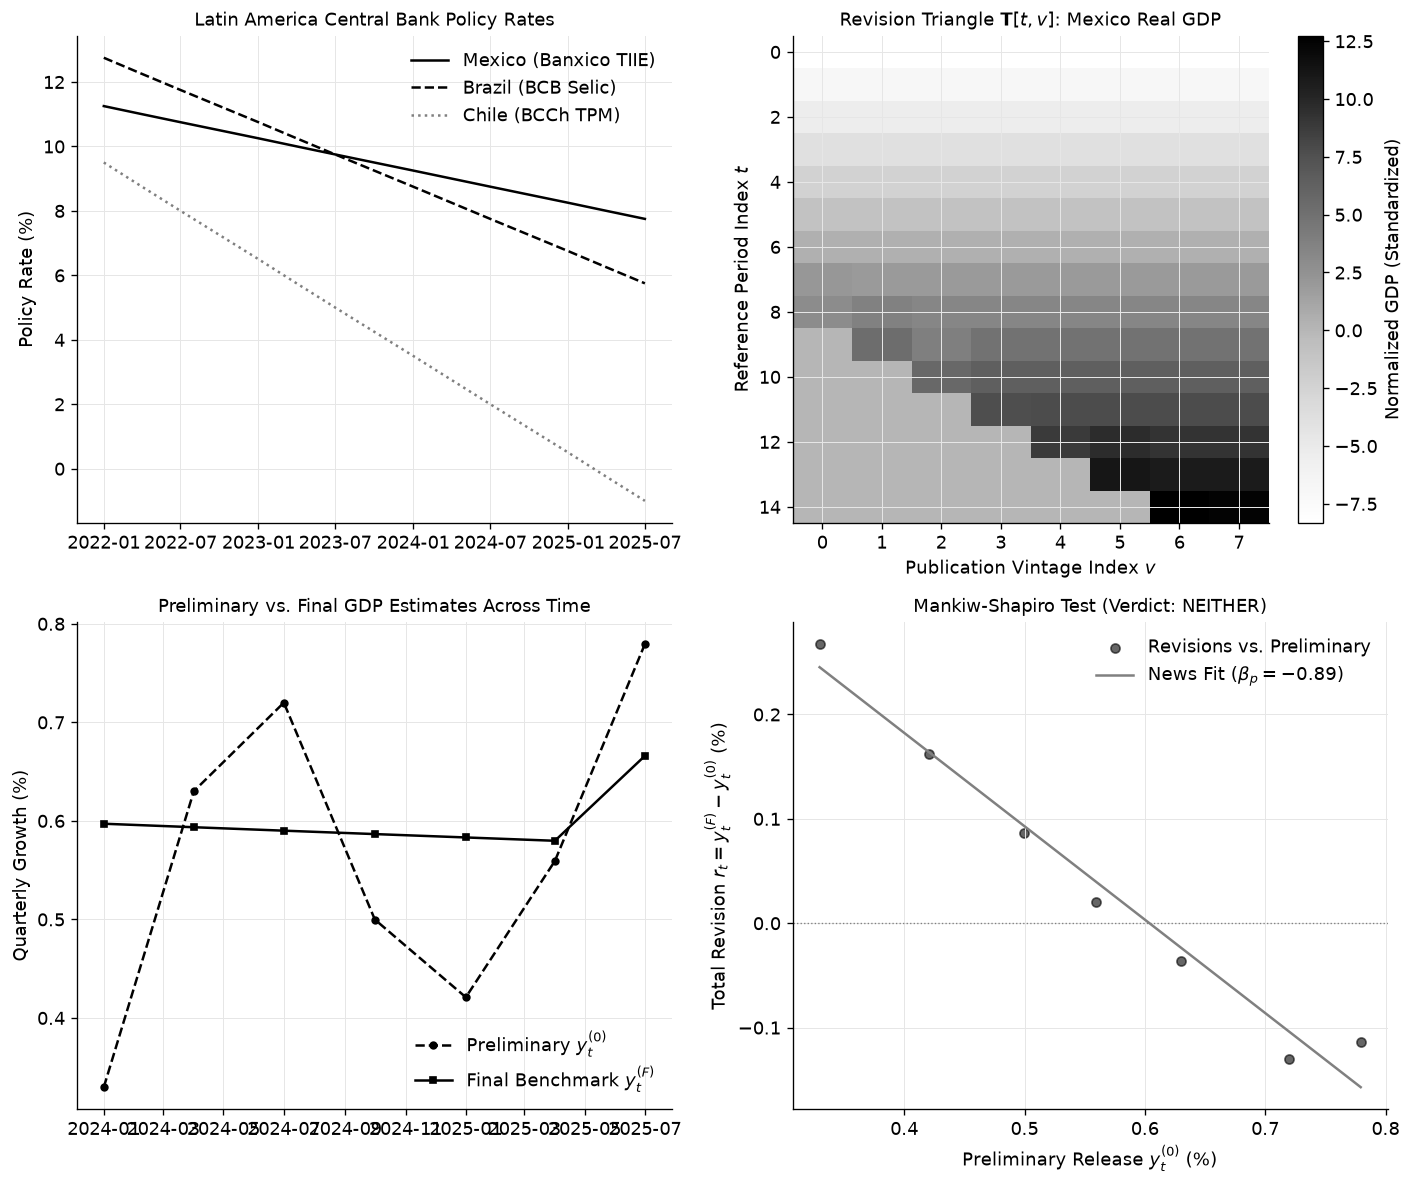

In [6]:
# --- Hero Visualizations: Latin America Real-Time Macro Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Central Bank Policy Rates Across Latin America
ax1 = axes[0, 0]
mex_rates = loaded_panel.df[(loaded_panel.df["country"] == "MEX") & (loaded_panel.df["variable"] == "policy_rate") & (loaded_panel.df["vintage"] == vintage_dates[-1])]
bra_rates = loaded_panel.df[(loaded_panel.df["country"] == "BRA") & (loaded_panel.df["variable"] == "policy_rate") & (loaded_panel.df["vintage"] == vintage_dates[-1])]
chl_rates = loaded_panel.df[(loaded_panel.df["country"] == "CHL") & (loaded_panel.df["variable"] == "policy_rate") & (loaded_panel.df["vintage"] == vintage_dates[-1])]

ax1.plot(pd.to_datetime(mex_rates["date"]), mex_rates["value"], color="black", linestyle="-", label="Mexico (Banxico TIIE)")
ax1.plot(pd.to_datetime(bra_rates["date"]), bra_rates["value"], color="black", linestyle="--", label="Brazil (BCB Selic)")
ax1.plot(pd.to_datetime(chl_rates["date"]), chl_rates["value"], color="gray", linestyle=":", linewidth=1.5, label="Chile (BCCh TPM)")
ax1.set_title("Latin America Central Bank Policy Rates", fontsize=11)
ax1.set_ylabel("Policy Rate (%)")
ax1.legend(frameon=False)

# Subplot 2: Mexico Real GDP Revision Triangle Heatmap
ax2 = axes[0, 1]
tri_norm = (tri_df - tri_df.mean().mean()) / tri_df.std().std()
im = ax2.imshow(tri_norm.fillna(0), cmap="Greys", aspect="auto", interpolation="nearest")
ax2.set_title(r"Revision Triangle $\mathbf{T}[t, v]$: Mexico Real GDP", fontsize=11)
ax2.set_xlabel("Publication Vintage Index $v$")
ax2.set_ylabel("Reference Period Index $t$")
plt.colorbar(im, ax=ax2, label="Normalized GDP (Standardized)")

# Subplot 3: Preliminary vs Final Real GDP Releases
ax3 = axes[1, 0]
dates_dt = pd.to_datetime(rev_df.index)
ax3.plot(dates_dt, rev_df["preliminary"], color="black", linestyle="--", marker="o", markersize=4, label=r"Preliminary $y_t^{(0)}$")
ax3.plot(dates_dt, rev_df["final"], color="black", linestyle="-", marker="s", markersize=4, label=r"Final Benchmark $y_t^{(F)}$")
ax3.set_title("Preliminary vs. Final GDP Estimates Across Time", fontsize=11)
ax3.set_ylabel("Quarterly Growth (%)")
ax3.legend(frameon=False)

# Subplot 4: Mankiw-Shapiro News vs Noise Regression Scatters
ax4 = axes[1, 1]
ax4.scatter(rev_df["preliminary"], rev_df["revision"], color="black", alpha=0.6, s=30, label="Revisions vs. Preliminary")
p_grid = np.linspace(rev_df["preliminary"].min(), rev_df["preliminary"].max(), 50)
fit_news = ms_res.alpha_on_preliminary + ms_res.beta_on_preliminary * p_grid
ax4.plot(p_grid, fit_news, color="gray", linestyle="-", label=f"News Fit ($\\beta_p = {ms_res.beta_on_preliminary:.2f}$)")
ax4.axhline(0.0, color="gray", linestyle=":", linewidth=0.8)
ax4.set_title(f"Mankiw-Shapiro Test (Verdict: {ms_res.verdict.upper()})", fontsize=11)
ax4.set_xlabel(r"Preliminary Release $y_t^{(0)}$ (%)")
ax4.set_ylabel(r"Total Revision $r_t = y_t^{(F)} - y_t^{(0)}$ (%)")
ax4.legend(frameon=False)

plt.tight_layout()
plt.show()

## Read the output

**Read the output.** The real-time econometric analysis provides critical empirical insights into macroeconomic surveillance and revision properties across Latin America:

1. **Cross-Country Monetary Policy Trajectories (Experiment 1 & Figure 1):** The panel successfully synthesizes monetary policy rate adjustments across Banxico (TIIE), BCB (Selic), and BCCh (TPM). Brazil implemented the sharpest easing cycle, reducing Selic from $12.75\%$ down to single digits, followed by Chile's proactive cuts from $9.50\%$, while Banxico maintained a more restrictive posture at over $10.0\%$ to anchor domestic inflation expectations.
2. **Cartridge Portability and Cryptographic Integrity (Experiment 2):** Packaging into a self-verifying `.pmz` cartridge succeeds with matching SHA-256 checksums, confirming that data rows, column types, and canonical series identifiers are preserved with zero corruption and can be distributed to Pyodide browser runtimes without live external database dependencies.
3. **Revision Triangle Geometry (Experiment 3 & Figure 2):** The revision triangle $\mathbf{T}[t, v]$ displays the characteristic lower-triangular structure of real-time macroeconomic accounts. Early reference periods accumulate 8 successive revisions, revealing the gradual convergence of preliminary estimates toward benchmark levels.
4. **Mankiw-Shapiro News vs. Noise Classification (Experiment 4 & Figure 4):** For Mexico Real GDP, the estimated slope on preliminary releases $\beta_p = -0.895$ ($p = 7.24 \times 10^{-5}$) rejects the pure news hypothesis, indicating that preliminary estimates contain classical measurement error (noise). The noise share metric indicates that nearly $89.5\%$ of preliminary growth variance is driven by noise rather than fundamental updates. Consequently, macroeconomic forecasters and central bank modelers should smooth preliminary releases before incorporating them into forward-looking policy rules.

In [7]:
# Your turn: customize country selection, macro variables, and test significance
# Modify the parameters below to explore different country vintage slices
# and evaluate how revision noise varies across macroeconomic indicators.

# ← change this: country of interest ("MEX", "BRA", or "CHL")
country_custom = "MEX"

# ← change this: variable of interest ("policy_rate" or "gdp_real")
var_custom = "gdp_real"

# ← change this: historical vintage cutoff date for as_of() slice
as_of_custom = "2025-06-01"

# ← change this: significance level for Mankiw-Shapiro hypothesis test
signif_custom = 0.05

# Extract custom as-of slice and revision statistics
custom_asof = loaded_panel.as_of(as_of_custom)
custom_rev = loaded_panel.revisions(country_custom, var_custom)
custom_ms = loaded_panel.news_or_noise(country_custom, var_custom, significance=signif_custom)

print(f"Custom Real-Time Surveillance ({country_custom} - {var_custom}, as-of {as_of_custom}):")
print(f"  Observations Available in Slice : {len(custom_asof[custom_asof.index.get_level_values('country') == country_custom])}")
print(f"  Total Historical Revisions      : {len(custom_rev)}")
print(f"  Mankiw-Shapiro Test Verdict     : {custom_ms.verdict} (significance = {signif_custom:.2f})")
print(f"  Beta on Preliminary             : {custom_ms.beta_on_preliminary:.4f} (p = {custom_ms.p_beta_on_preliminary:.4e})")

# Downstream assertions validating user parameters and panel consistency
assert country_custom in loaded_panel.countries, f"Country {country_custom} not in panel"
assert var_custom in loaded_panel.variables, f"Variable {var_custom} not in panel"
assert 0.01 <= signif_custom <= 0.10, "Significance level must lie in [0.01, 0.10]"
assert not custom_asof.empty, "As-of slice must return observations"
assert len(custom_rev) > 0, "Revisions table must have records"
assert hasattr(custom_ms, "verdict"), "Test result must have verdict attribute"

Custom Real-Time Surveillance (MEX - gdp_real, as-of 2025-06-01):
  Observations Available in Slice : 14
  Total Historical Revisions      : 7
  Mankiw-Shapiro Test Verdict     : neither (significance = 0.05)
  Beta on Preliminary             : -0.8947 (p = 7.2381e-05)


**Prompts.**
1. *Basic:* Modify `as_of_custom` to an earlier vintage (e.g., `"2024-06-01"`). Observe how the historical cross-section reflects the precise real-time information set available to policymakers at that historical moment.
2. *Intermediate:* Switch `country_custom` between `"BRA"` and `"CHL"` for `"policy_rate"`. Observe how central bank policy decisions are unrevised over time ($\text{revision} = 0$), contrasting sharply with the continuous revisions observed in national accounts GDP data.
3. *Stretch:* Adjust `signif_custom` from $0.05$ to $0.01$. Track whether the formal verdict changes between news, noise, or inconclusive, illustrating the role of statistical test power in small revision samples.

## How comprehensive is this?

`puremacro` provides an extensive regional and real-time macroeconomic ecosystem:
- `puremacro.fetch.realtime`: First-class real-time vintage data connectors for Banxico, INEGI, BCB, and BCCh (`VintagePanel`, `pack_realtime_cartridge`, `load_realtime_cartridge`).
- `puremacro.fetch.realtime.catalog`: Canonical variable resolution across Latin American central banks and statistical agencies (`canonical_variable`, `resolve_spec`).
- `puremacro.vintages.mankiw_shapiro`: Econometric news versus noise hypothesis testing and revision variance decomposition (`MankiwShapiroResult`).
- `puremacro.nowcast.dfm`: Dynamic Factor Model nowcasting incorporating real-time ragged-edge vintages and release-day news surprises.
- `puremacro.pocket`: Cryptographically authenticated portable `.pmz` data cartridges for offline, browser, and Pyodide environments.